In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load the Titanic Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/MCA/Sem 3/ML/Practical/Practical-3/Titanic-Dataset.csv")
df.head()
print(df.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## Data Preprocessing

In [ ]:

display(df.info())

display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

None

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df_processed = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)

df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0], inplace=True)

df_processed = pd.get_dummies(df_processed, columns=['Sex', 'Embarked'], drop_first=True)

display(df_processed.head())
display(df_processed.isnull().sum())

/tmp/ipykernel_1432/1362432787.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
/tmp/ipykernel_1432/1362432787.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
Sex_male,0
Embarked_Q,0
Embarked_S,0


## Feature Scaling

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)

X_scaled_df = pd.DataFrame(X_scaled, columns=df_processed.columns)

display(X_scaled_df.head())

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,-0.789272,0.827377,-0.565736,0.432793,-0.473674,-0.502445,0.737695,-0.307562,0.615838
1,1.266990,-1.566107,0.663861,0.432793,-0.473674,0.786845,-1.355574,-0.307562,-1.623803
2,1.266990,0.827377,-0.258337,-0.474545,-0.473674,-0.488854,-1.355574,-0.307562,0.615838
3,1.266990,-1.566107,0.433312,0.432793,-0.473674,0.420730,-1.355574,-0.307562,0.615838
4,-0.789272,0.827377,0.433312,-0.474545,-0.473674,-0.486337,0.737695,-0.307562,0.615838


## Hierarchical Clustering

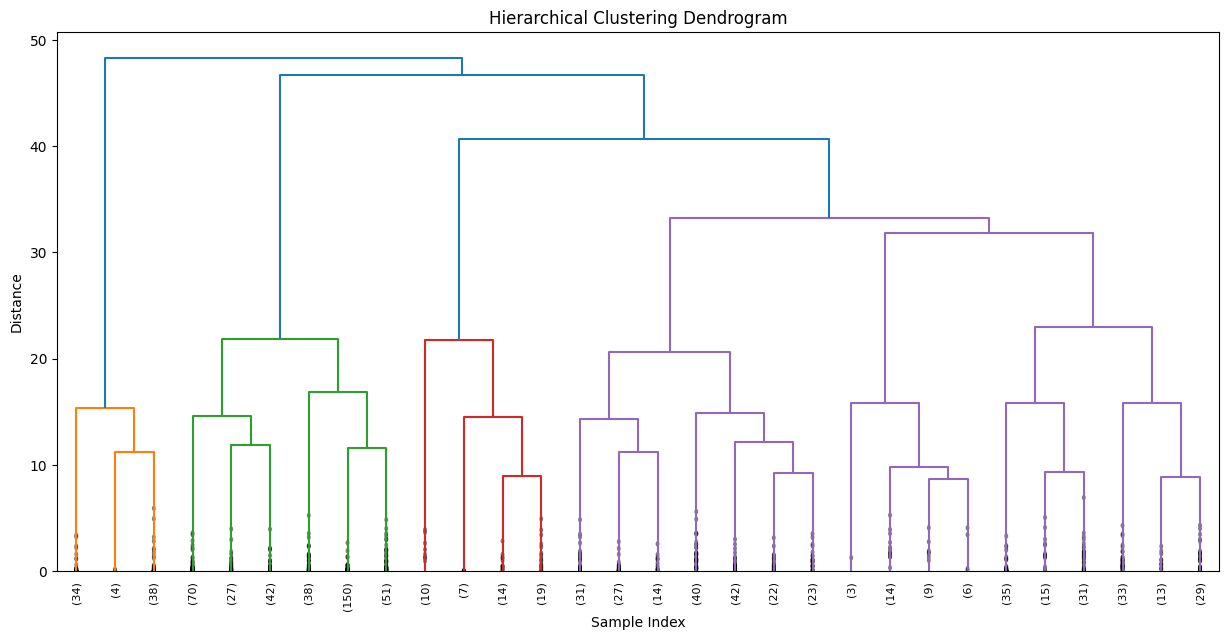

In [ ]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True,
)
plt.show()

In [ ]:
n_clusters = 3
hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
df_processed['Cluster'] = hc.fit_predict(X_scaled)

display(df_processed['Cluster'].value_counts())

display(df_processed.head())

,count
Cluster,
0,437
2,378
1,76


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Cluster
0,0,3,22.0,1,0,7.2500,True,False,True,2
1,1,1,38.0,1,0,71.2833,False,False,False,0
2,1,3,26.0,0,0,7.9250,False,False,True,0
3,1,1,35.0,1,0,53.1000,False,False,True,0
4,0,3,35.0,0,0,8.0500,True,False,True,2


## Cluster Analysis

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
Cluster,,,,,,,,,
0,0.713959,2.022883,28.118238,0.784897,0.661327,49.737739,0.448513,0.002288,0.613272
1,0.394737,2.907895,27.888158,0.434211,0.105263,13.067491,0.539474,1.000000,0.000000
2,0.000000,2.518519,31.095238,0.238095,0.113757,15.781556,0.899471,0.000000,1.000000


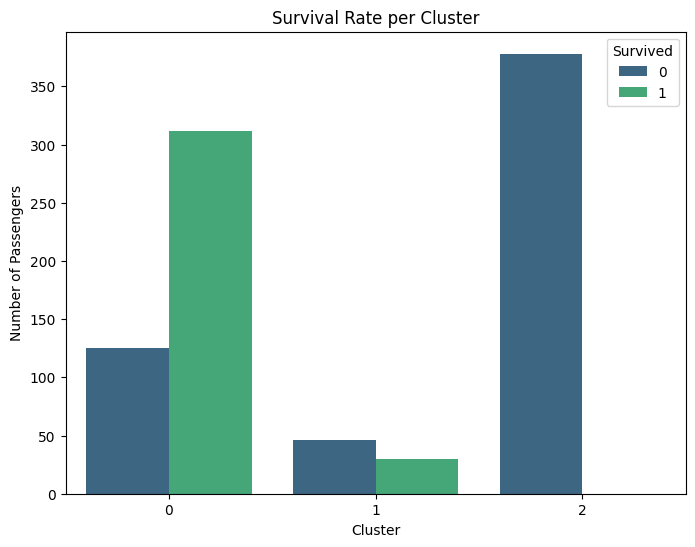

In [ ]:

cluster_summary = df_processed.groupby('Cluster').mean()
display(cluster_summary)

plt.figure(figsize=(8, 6))
sns.countplot(x='Cluster', hue='Survived', data=df_processed, palette='viridis')
plt.title('Survival Rate per Cluster')
plt.ylabel('Number of Passengers')
plt.show()

## Conclusion

In [ ]:
print("Hierarchical clustering successfully applied to the Titanic dataset.")
print("Three distinct clusters have been formed, and their characteristics are summarized above.")
print("The survival rate also varies across these clusters, indicating that our clustering has captured meaningful patterns in the data.")

Hierarchical clustering successfully applied to the Titanic dataset.
Three distinct clusters have been formed, and their characteristics are summarized above.
The survival rate also varies across these clusters, indicating that our clustering has captured meaningful patterns in the data.
